In [420]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.animation as animation

from matplotlib.colors import ListedColormap

%matplotlib inline

# Simple Spatial SIR

In [421]:
# Parameters
n = 32
N = n**2

beta = 0.5/7      # Infection prob
gamma = 0.3/7     # Recovery prob

tmax = 1000
T = tmax
ts = np.arange(0,tmax+1,1)

grids = np.zeros((tmax+1,n,n))

grids[0,int(n/2):int(n/2)+2,int(n/2):int(n/2)+2] = 1

rng = np.random.default_rng(30)

for t in range(tmax):
    infected_mask = np.zeros((n+2,n+2))
    infected_mask[1:-1,1:-1] = grids[t] == 1

    if (np.sum(infected_mask) == 0):
        T = t-1
        break

    infected_neighbours = (infected_mask[:-2,:-2] + # Upper left
                            infected_mask[1:-1,:-2] + # Left
                            infected_mask[2:,:-2] + # Lower left
                            infected_mask[2:,1:-1] + # Lower
                            infected_mask[2:,2:] + # Lower right
                            infected_mask[1:-1,2:] + # Right
                            infected_mask[:-2,2:] + # Upper right
                            infected_mask[:-2,1:-1] # Upper
                            )

    for i in range(n):
        for j in range(n):
            if (grids[t,i,j] == 0 and infected_neighbours[i,j] > 0):
                infect = rng.binomial(n=int(infected_neighbours[i,j]), p=beta)
                if (infect > 0):
                    grids[t+1,i,j] = 1
            if (grids[t,i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                if (recover == 0):
                    grids[t+1,i,j] = 1
                if (recover == 1):
                    grids[t+1:,i,j] = 2

In [426]:
%matplotlib inline

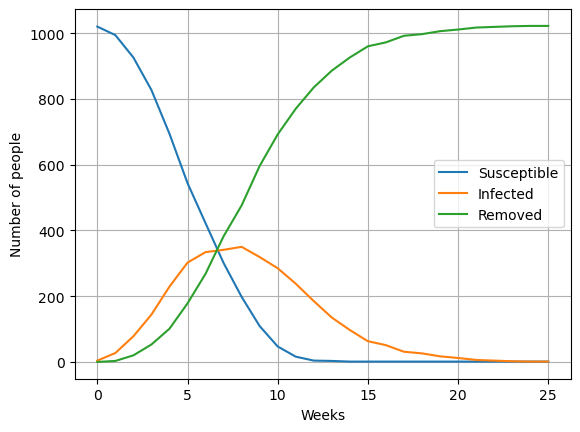

In [424]:
n_s = np.zeros(tmax+1)
n_i = np.zeros(tmax+1)
n_r = np.zeros(tmax+1)
for i in range(tmax+1):
    n_s[i] = np.sum(grids[i,:,:] == 0)
    n_i[i] = np.sum(grids[i,:,:] == 1)
    n_r[i] = np.sum(grids[i,:,:] == 2)

plt.plot(n_s[:T:7], label='Susceptible')
plt.plot(n_i[:T:7], label='Infected')
plt.plot(n_r[:T:7], label='Removed')

plt.legend()
plt.xlabel('Weeks')
plt.ylabel('Number of people')
plt.grid()
plt.show()

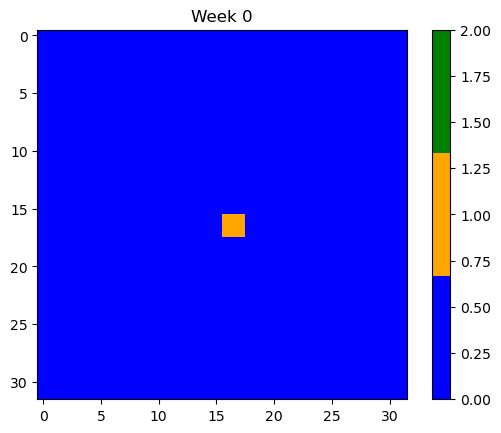

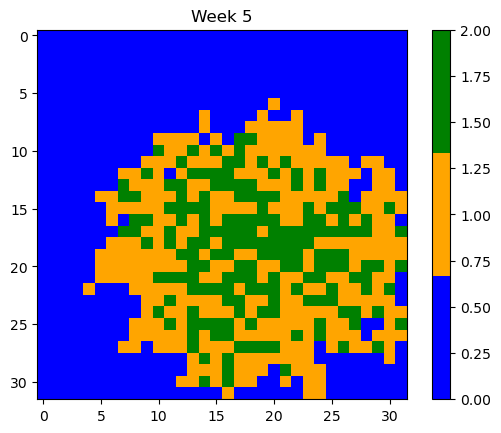

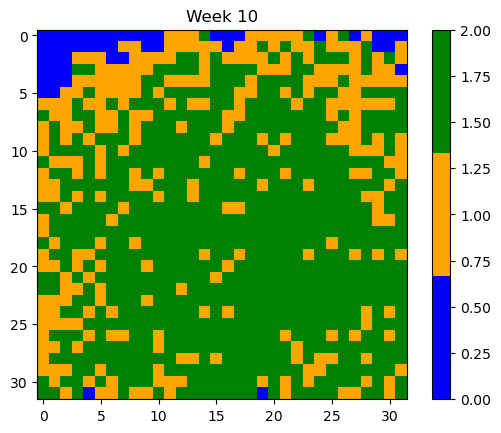

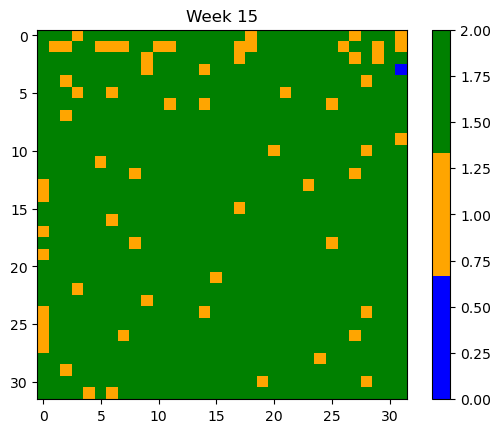

In [436]:
cmap = ListedColormap(['blue', 'orange', 'green'])

plt.imshow(grids[0], cmap=cmap, vmax=2)
plt.title('Week 0')
plt.colorbar()
plt.show()

plt.imshow(grids[5*7], cmap=cmap, vmax=2)
plt.title('Week 5')
plt.colorbar()
plt.show()

plt.imshow(grids[10*7], cmap=cmap, vmax=2)
plt.title('Week 10')
plt.colorbar()
plt.show()

plt.imshow(grids[15*7], cmap=cmap, vmax=2)
plt.title('Week 15')
plt.colorbar()
plt.show()

In [ ]:
stop

%matplotlib qt

fig = plt.figure()

im = plt.imshow(grids[0], animated=True, cmap=cmap)

def updatefig(frame):
    im = plt.imshow(grids[frame], animated=True, cmap=cmap)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=ts[:T], interval=200)

plt.colorbar()

#ani.save(filename="pillow_example.gif", writer="pillow")

plt.show()

# asd

In [407]:
# Parameters
n = 100
N = n**2

#beta = 0.5      # Infection prob
#gamma = 0.3     # Recovery prob
#d = 0.005

beta = 0.3/7
gamma = 0.5/7
d = 0

prob = 0.01

tmax = 1000
T = tmax
ts = np.arange(0,tmax+1,1)

grids = np.zeros((tmax+1,n,n))


#grids[0,0,0] = 1
#grids[0,0,-1] = 1
#grids[0,-1,0] = 1
#grids[0,-1,-1] = 1

grids[0,int(n/2):int(n/2)+2,int(n/2):int(n/2)+2] = 1

#grids[0,int(n/2):int(n/2)+5,int(n/2):int(n/2)+5] = 1

#grids[:,16,0:16] = 4

rng = np.random.default_rng(30)

for t in range(tmax):
    infected_mask = np.zeros((n+2,n+2))
    infected_mask[1:-1,1:-1] = grids[t] == 1

    if (np.sum(infected_mask) == 0):
        T = t-1
        break

    infected_neighbours = (infected_mask[:-2,:-2] + # Upper left
                            infected_mask[1:-1,:-2] + # Left
                            infected_mask[2:,:-2] + # Lower left
                            infected_mask[2:,1:-1] + # Lower
                            infected_mask[2:,2:] + # Lower right
                            infected_mask[1:-1,2:] + # Right
                            infected_mask[:-2,2:] + # Upper right
                            infected_mask[:-2,1:-1] # Upper
                            )
    

    for i in range(n):
        for j in range(n):
            if (grids[t,i,j] == 0 and infected_neighbours[i,j] > 0):
                infect = rng.binomial(n=int(infected_neighbours[i,j]), p=beta)
                if (infect > 0):
                    grids[t+1,i,j] = 1
            if (grids[t,i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                die = rng.binomial(n=1, p=d)
                if (recover == 0):
                    grids[t+1,i,j] = 1
                if (recover == 1 and die == 0):
                    grids[t+1:,i,j] = 2
                #if (recover == 0 and die == 1):
                #    grids[t+1:,i,j] = 3

    for k in range(int(np.sum(infected_mask))):
        random_infect = rng.choice(a=2, size=1, p=[1-prob, prob])
        if (random_infect == 0):
            continue
        if (random_infect == 1):
            x = rng.choice(n)
            y = rng.choice(n)
            if (grids[t+1,x,y] == 0):
                grids[t+1,x,y] = 1




            #infected = False
            #while (infected == False):
            #    x = rng.choice(n)
            #    y = rng.choice(n)
            #    if (grids[t+1,x,y] == 0):
            #        grids[t+1,x,y] = 1
            #        infected = True

In [412]:
%matplotlib inline

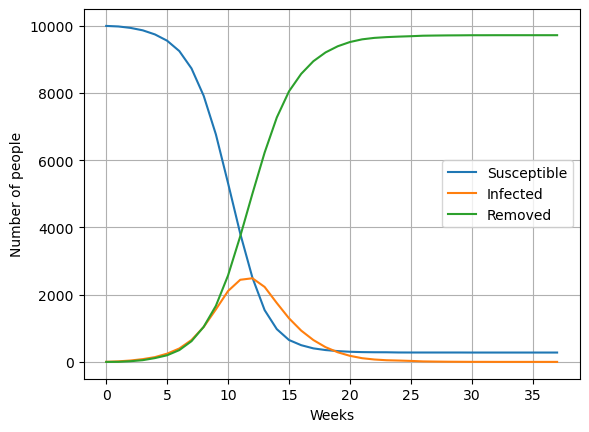

In [413]:
n_s = np.zeros(tmax+1)
n_i = np.zeros(tmax+1)
n_r = np.zeros(tmax+1)
n_d = np.zeros(tmax+1)
for i in range(tmax+1):
    n_s[i] = np.sum(grids[i,:,:] == 0)
    n_i[i] = np.sum(grids[i,:,:] == 1)
    n_r[i] = np.sum(grids[i,:,:] == 2)
    n_d[i] = np.sum(grids[i,:,:] == 3)

plt.plot(n_s[:T:7], label='Susceptible')
plt.plot(n_i[:T:7], label='Infected')
plt.plot(n_r[:T:7], label='Removed')
#plt.plot(n_d[:T], label='Dead')

plt.legend()
plt.xlabel('Weeks')
plt.ylabel('Number of people')
plt.grid()
plt.show()

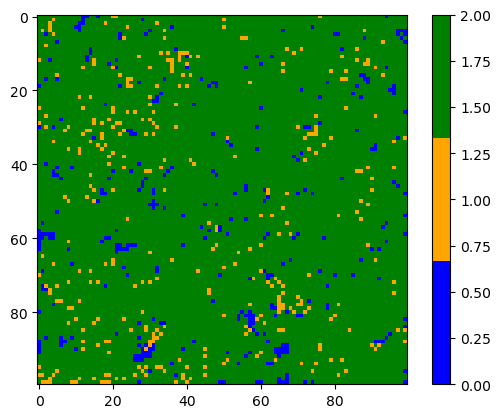

In [410]:
cmap = ListedColormap(['blue', 'orange', 'green'])

plt.imshow(grids[int(T/2)], cmap=cmap)
#plt.imshow(grids[T], cmap=cmap)
plt.colorbar()
plt.show()

In [411]:
#stop

%matplotlib qt

fig = plt.figure()

im = plt.imshow(grids[0], animated=True, cmap=cmap)

def updatefig(frame):
    im = plt.imshow(grids[frame], animated=True, cmap=cmap)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=ts[:T], interval=200)

#plt.colorbar()

#ani.save(filename="pillow_example.gif", writer="pillow")

plt.show()